# Rice Dataset: Pooled Top-k Ranking Experiment

This notebook runs a ranking-based LazyFCA experiment on the rice dataset.

Main idea:
- keep the usual baseline thresholds only as a permissive pre-filter,
- for each query object, pool positive and negative classifiers together,
- rank the pooled classifiers by one chosen metric,
- keep only the Top-k classifiers from that pooled list,
- classify using only those Top-k classifiers,
- plot F1 as a function of k.

This differs from the threshold notebook because it does not sweep a metric threshold. Instead, it turns the explanation into a ranked list and truncates it directly.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MPLCONFIGDIR = ROOT / "experiments" / ".matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection
import tqdm.auto as tqdm

PLOTS_DIR = ROOT / "experiments" / "generated_plots" / "sonar_topk_ranking_raw"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

from lazyfca.lazyfca import LazyFCA
from utils.estimate_quality import estimate_quality

/home/toretto/miniconda3/envs/lazyfca/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
pd.set_option("display.max_columns", None)

data = pd.read_csv("../datasets/sonar.csv")
data["class"] = data["class"].map({"R": 0, "M": 1})

X = data.drop(columns=["class"])
y = data["class"].to_numpy()

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

X_train.shape, X_test.shape


((166, 60), (42, 60))

## Baseline Threshold Params

`LazyFCA.Params(...)` is the threshold object used by LazyFCA.

Important detail:
- this object reuses the same dataclass as the metrics themselves,
- but when passed into `LazyFCA(...)`, its values are interpreted as lower/upper bounds for filtering classifiers.

Example:
- `supporters_covered=1` means keep only classifiers covering at least 1 supporter,
- `supporter_opposer_ratio=1.0` means keep only classifiers whose supporter/opposer ratio is at least 1.0.

Here we keep the same baseline thresholds as in the original rice notebook. They serve only as a permissive pre-filter before ranking.

In [21]:
baseline_classifier = LazyFCA()
baseline_classifier.fit(X_train, y_train)

In [22]:
# Baseline threshold-only performance for reference.
baseline_y_pred = baseline_classifier.predict(X_test)
baseline_metrics = estimate_quality(baseline_y_pred, y_test)
baseline_metrics

100%|██████████| 42/42 [00:00<00:00, 308.37it/s]


{'Accuracy': 0.5238095238095238,
 'Precision': 0.5238095238095238,
 'Recall': 1.0,
 'AUC-ROC': 0.5,
 'F1-score': 0.6875,
 'True Positive': np.int64(22),
 'True Negative': np.int64(0),
 'False Positive': np.int64(20),
 'False Negative': np.int64(0),
 'True Negative Rate (Specificity)': np.float64(0.0),
 'Negative Predictive Value': 0,
 'False Positive Rate': np.float64(1.0),
 'False Discovery Rate': np.float64(0.47619047619047616)}

## Precompute Explanations Once

Efficiency idea:
- explanations are the expensive part,
- threshold sweeps or top-k sweeps should not recompute them,
- we precompute them once using the baseline threshold filter,
- every metric/k experiment reuses those explanations.

In [23]:
explanations = baseline_classifier.explain(X_test)
len(explanations)

100%|██████████| 42/42 [00:00<00:00, 238.32it/s]


42

In [24]:
available_metrics = [
    "supporters_covered",
    "opposers_covered",
    "supporter_opposer_ratio",
    "support",
    "error_rate",
    "precision",
    "lift",
    "wracc",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "interval_tightness",
    "description_volume",
    "simplicity_prior",
    "query_binary_similarity",
    "query_numeric_similarity",
    "query_similarity",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "robustness",
    "delta_stability",
]

available_metrics

['supporters_covered',
 'opposers_covered',
 'supporter_opposer_ratio',
 'support',
 'error_rate',
 'precision',
 'lift',
 'wracc',
 'balanced_precision_proxy',
 'youdens_j',
 'matthews_correlation',
 'information_gain',
 'gini_gain',
 'log_odds_ratio',
 'chi_squared',
 'g_test',
 'interval_tightness',
 'description_volume',
 'simplicity_prior',
 'query_binary_similarity',
 'query_numeric_similarity',
 'query_similarity',
 'query_weighted_precision',
 'query_weighted_wracc',
 'stability',
 'robustness',
 'delta_stability']

## Efficient Pooled Top-k Evaluation

For each explanation and each metric:
1. put positive and negative classifiers in one pooled list,
2. score them by the chosen metric,
3. sort descending,
4. compute cumulative counts of positive and negative classifiers,
5. reuse those cumulative counts for all values of k.

This makes each metric experiment much faster than recomputing `predict()` for every k.

In [25]:
MINIMIZED_METRICS = {"opposers_covered", "error_rate", "description_volume"}

def metric_score(classifier, metric_name):
    value = getattr(classifier.get_metrics(), metric_name)
    return -value if metric_name in MINIMIZED_METRICS else value

def build_metric_cache(explanations, metric_name):
    cache = []
    for explanation in tqdm.tqdm(explanations, desc=f"Caching {metric_name}"):
        pooled = [
            *[(metric_score(clf, metric_name), 1) for clf in explanation.positive_classifiers],
            *[(metric_score(clf, metric_name), 0) for clf in explanation.negative_classifiers],
        ]

        if not pooled:
            cache.append({
                "total": 0,
                "cum_pos": np.array([], dtype=np.int32),
                "cum_neg": np.array([], dtype=np.int32),
            })
            continue

        pooled.sort(key=lambda item: item[0], reverse=True)
        labels = np.array([label for _, label in pooled], dtype=np.int32)
        cum_pos = np.cumsum(labels)
        cum_neg = np.cumsum(1 - labels)

        cache.append({
            "total": len(labels),
            "cum_pos": cum_pos,
            "cum_neg": cum_neg,
        })

    return cache

def predict_from_metric_cache(metric_cache, k, pos_weight=1.0):
    y_pred = np.zeros((len(metric_cache), 2), dtype=np.float64)

    for i, item in enumerate(metric_cache):
        total_available = item["total"]
        if total_available == 0 or k <= 0:
            y_pred[i] = [0.5, 0.5]
            continue

        take = min(k, total_available)
        pos_count = int(item["cum_pos"][take - 1])
        neg_count = int(item["cum_neg"][take - 1])

        weighted_pos = pos_weight * pos_count
        total = weighted_pos + neg_count
        if total == 0:
            y_pred[i] = [0.5, 0.5]
        else:
            y_pred[i] = [neg_count / total, weighted_pos / total]

    return y_pred

def evaluate_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_test, pos_weight=1.0):
    metric_cache = build_metric_cache(explanations, metric_name)
    rows = []

    for k in tqdm.tqdm(k_values, desc=f"Evaluating {metric_name}"):
        y_pred = predict_from_metric_cache(metric_cache, k, pos_weight=pos_weight)
        metrics = estimate_quality(y_pred, y_true)
        avg_kept = float(np.mean([min(k, item["total"]) for item in metric_cache]))
        rows.append({
            "k": int(k),
            "F1-score": metrics["F1-score"],
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "AUC-ROC": metrics["AUC-ROC"],
            "Average classifiers kept": avg_kept,
        })

    return pd.DataFrame(rows)

def plot_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_test, pos_weight=1.0):
    results = evaluate_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_true, pos_weight=pos_weight)
    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]
    plot_path = PLOTS_DIR / f"{metric_name}_topk_f1.png"

    plt.figure(figsize=(12, 6))
    plt.plot(results["k"], results["F1-score"], marker="o", linewidth=2)
    plt.axhline(baseline_metrics["F1-score"], color="red", linestyle="--", label="Baseline threshold-only")
    plt.scatter([best_row["k"]], [best_row["F1-score"]], color="green", s=80, zorder=3, label="Best Top-k")
    plt.xlabel("Top-k")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs pooled Top-k for metric: {metric_name}")
    plt.xlim(results["k"].max(), results["k"].min())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {plot_path}")
    print(f"Best k for {metric_name}: {int(best_row['k'])}")
    print(f"Best F1-score: {best_row['F1-score']:.6f}")
    print(f"Average classifiers kept: {best_row['Average classifiers kept']:.2f}")

    return results

In [26]:
# Build a top-heavy k-grid from the actual number of pooled classifiers.
# It always includes 1 and the maximum available number of classifiers.
# The grid is intentionally dense near the full classifier count.
max_total_classifiers = max(
    len(explanation.positive_classifiers) + len(explanation.negative_classifiers)
    for explanation in explanations
)

def build_top_heavy_k_grid(max_k, dense_tail=80, mid_points=50, low_points=30):
    if max_k <= 1:
        return np.array([1], dtype=int)

    values = {1, max_k}

    tail_start = max(1, max_k - dense_tail + 1)
    values.update(range(tail_start, max_k + 1))

    t = np.linspace(0.0, 1.0, mid_points)
    mid = np.rint(1 + (max_k - 1) * (t ** 2)).astype(int)
    values.update(mid.tolist())

    low = np.geomspace(1, max_k, low_points)
    low = np.rint(low).astype(int)
    values.update(low.tolist())

    return np.array(sorted(values, reverse=True), dtype=int)

k_values = build_top_heavy_k_grid(max_total_classifiers, dense_tail=80, mid_points=50, low_points=30)
print("Max pooled classifiers:", max_total_classifiers)
print("Number of k values:", len(k_values))
print("First 25 k values:", k_values[:25])
print("Last 25 k values:", k_values[-25:])
k_values

Max pooled classifiers: 166
Number of k values: 122
First 25 k values: [166 165 164 163 162 161 160 159 158 157 156 155 154 153 152 151 150 149
 148 147 146 145 144 143 142]
Last 25 k values: [34 31 28 26 24 23 21 20 19 17 16 14 13 12 11 10  9  8  7  6  5  4  3  2
  1]


array([166, 165, 164, 163, 162, 161, 160, 159, 158, 157, 156, 155, 154,
       153, 152, 151, 150, 149, 148, 147, 146, 145, 144, 143, 142, 141,
       140, 139, 138, 137, 136, 135, 134, 133, 132, 131, 130, 129, 128,
       127, 126, 125, 124, 123, 122, 121, 120, 119, 118, 117, 116, 115,
       114, 113, 112, 111, 110, 109, 108, 107, 106, 105, 104, 103, 102,
       101, 100,  99,  98,  97,  96,  95,  94,  93,  92,  91,  90,  89,
        88,  87,  85,  82,  80,  76,  71,  69,  67,  63,  59,  58,  55,
        51,  48,  47,  44,  41,  37,  34,  31,  28,  26,  24,  23,  21,
        20,  19,  17,  16,  14,  13,  12,  11,  10,   9,   8,   7,   6,
         5,   4,   3,   2,   1])

## Example: WRAcc

Evaluating wracc: 100%|██████████| 122/122 [00:00<00:00, 140.87it/s]


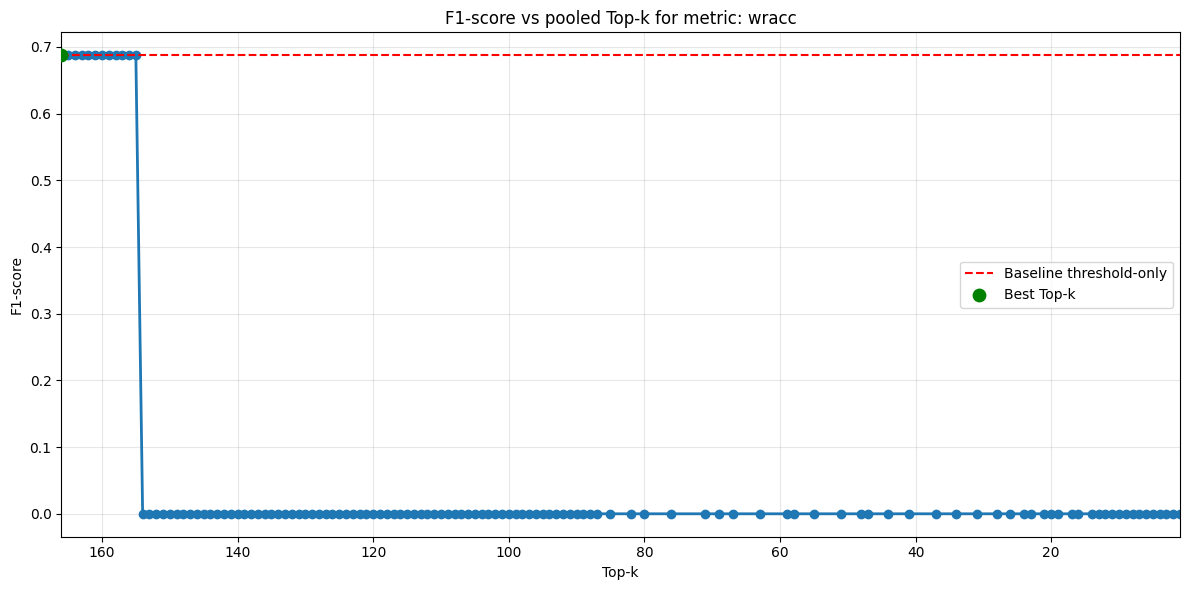

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/wracc_topk_f1.png
Best k for wracc: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00


,k,F1-score,Accuracy,Precision,Recall,AUC-ROC,Average classifiers kept
0,166,0.6875,0.52381,0.52381,1.0,0.5,166.0
1,165,0.6875,0.52381,0.52381,1.0,0.5,165.0
2,164,0.6875,0.52381,0.52381,1.0,0.5,164.0
3,163,0.6875,0.52381,0.52381,1.0,0.5,163.0
4,162,0.6875,0.52381,0.52381,1.0,0.5,162.0
...,...,...,...,...,...,...,...
117,5,0.0000,0.47619,0.00000,0.0,0.5,5.0
118,4,0.0000,0.47619,0.00000,0.0,0.5,4.0
119,3,0.0000,0.47619,0.00000,0.0,0.5,3.0
120,2,0.0000,0.47619,0.00000,0.0,0.5,2.0


In [27]:
wracc_results = plot_metric_topk("wracc", k_values)
wracc_results

## Run Any Metric

Examples:
- `plot_metric_topk("precision", k_values)`
- `plot_metric_topk("balanced_precision_proxy", k_values)`
- `plot_metric_topk("information_gain", k_values)`
- `plot_metric_topk("query_weighted_precision", k_values)`
- `plot_metric_topk("stability", k_values)`

Evaluating information_gain: 100%|██████████| 122/122 [00:00<00:00, 152.19it/s]


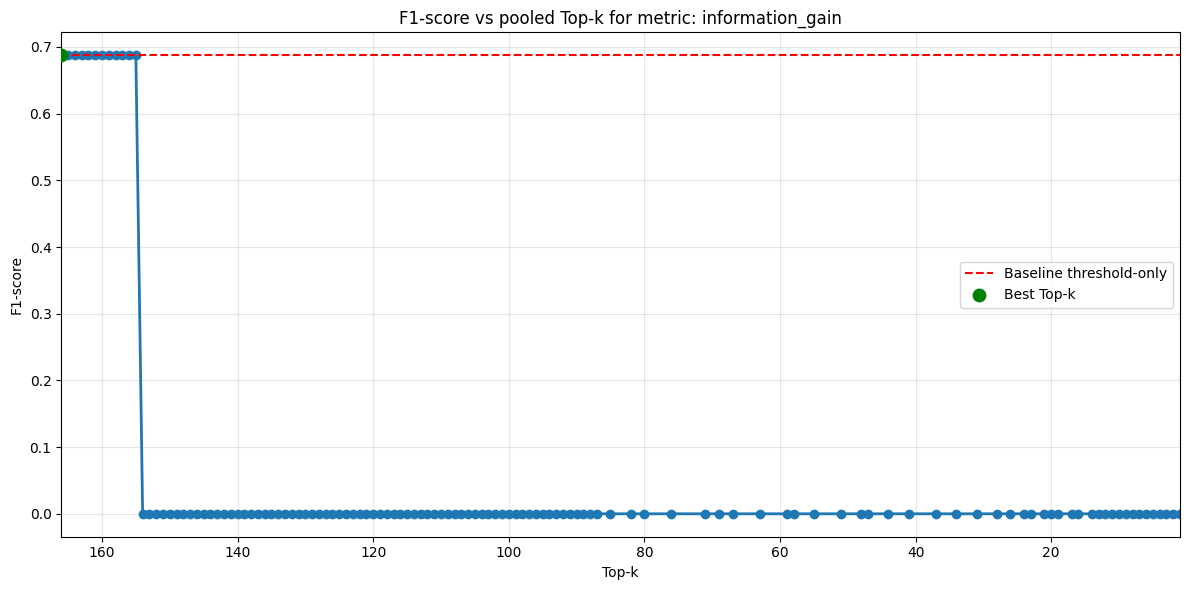

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/information_gain_topk_f1.png
Best k for information_gain: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00


,k,F1-score,Accuracy,Precision,Recall,AUC-ROC,Average classifiers kept
0,166,0.6875,0.52381,0.52381,1.0,0.5,166.0
1,165,0.6875,0.52381,0.52381,1.0,0.5,165.0
2,164,0.6875,0.52381,0.52381,1.0,0.5,164.0
3,163,0.6875,0.52381,0.52381,1.0,0.5,163.0
4,162,0.6875,0.52381,0.52381,1.0,0.5,162.0
...,...,...,...,...,...,...,...
117,5,0.0000,0.47619,0.00000,0.0,0.5,5.0
118,4,0.0000,0.47619,0.00000,0.0,0.5,4.0
119,3,0.0000,0.47619,0.00000,0.0,0.5,3.0
120,2,0.0000,0.47619,0.00000,0.0,0.5,2.0


In [28]:
metric_name = "information_gain"
results = plot_metric_topk(metric_name, k_values)
results

## Batch Run Over Several Metrics

This cell is optional. It can take time, but it is still much cheaper than recomputing explanations for every metric and every k.

In [29]:
metrics_to_try = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

summary_rows = []
for metric_name in metrics_to_try:
    results = evaluate_metric_topk(metric_name, k_values)
    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]
    summary_rows.append({
        "metric": metric_name,
        "best_k": int(best_row["k"]),
        "best_f1": best_row["F1-score"],
        "avg_classifiers_kept": best_row["Average classifiers kept"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="best_f1", ascending=False)
summary_df

Evaluating delta_stability: 100%|██████████| 122/122 [00:00<00:00, 145.17it/s]


,metric,best_k,best_f1,avg_classifiers_kept
8,query_weighted_precision,2,0.926829,2.0
0,wracc,166,0.687500,166.0
2,balanced_precision_proxy,166,0.687500,166.0
1,lift,166,0.687500,166.0
3,matthews_correlation,166,0.687500,166.0
4,information_gain,166,0.687500,166.0
6,chi_squared,166,0.687500,166.0
5,gini_gain,166,0.687500,166.0
7,g_test,166,0.687500,166.0
9,query_weighted_wracc,166,0.687500,166.0



=== wracc ===


Evaluating wracc: 100%|██████████| 122/122 [00:00<00:00, 148.15it/s]


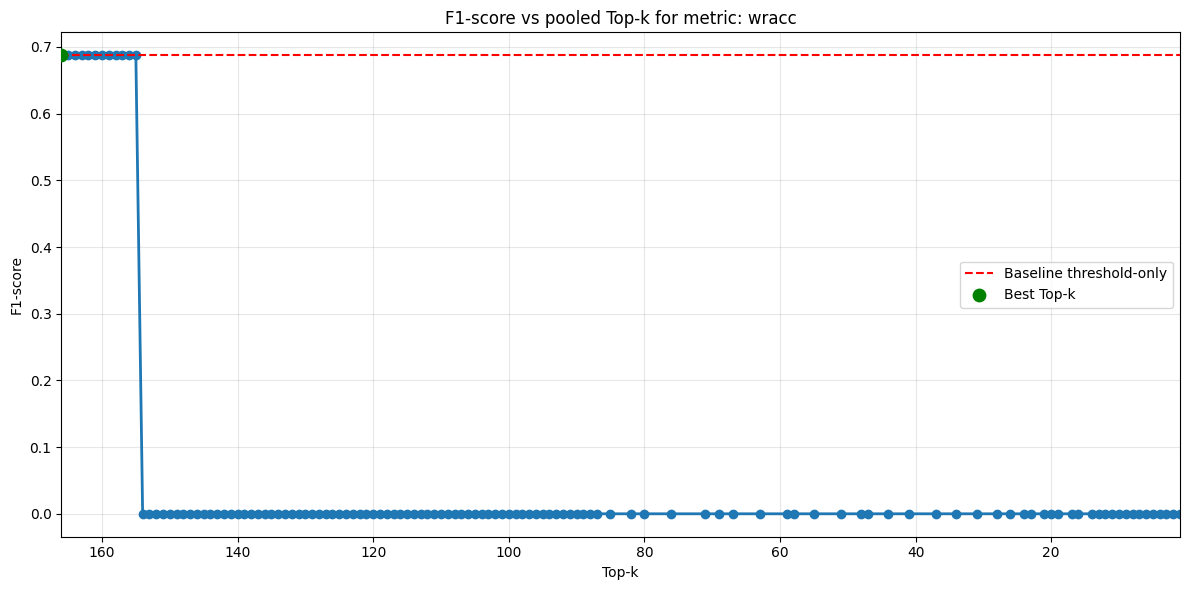

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/wracc_topk_f1.png
Best k for wracc: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== lift ===


Evaluating lift: 100%|██████████| 122/122 [00:00<00:00, 146.15it/s]


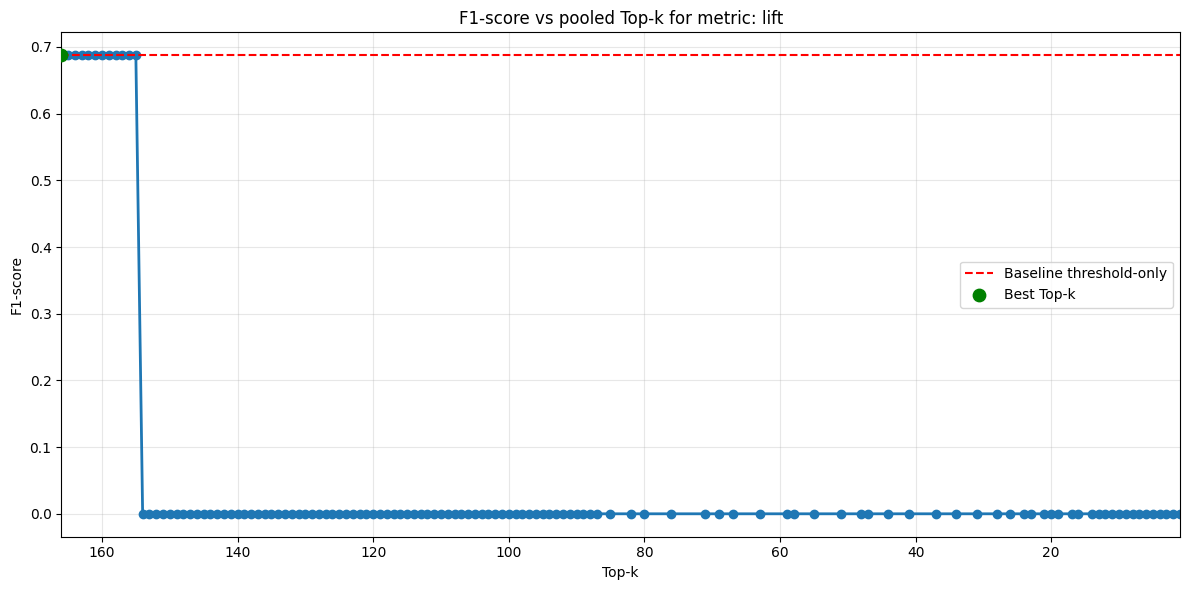

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/lift_topk_f1.png
Best k for lift: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== balanced_precision_proxy ===


Evaluating balanced_precision_proxy: 100%|██████████| 122/122 [00:00<00:00, 148.66it/s]


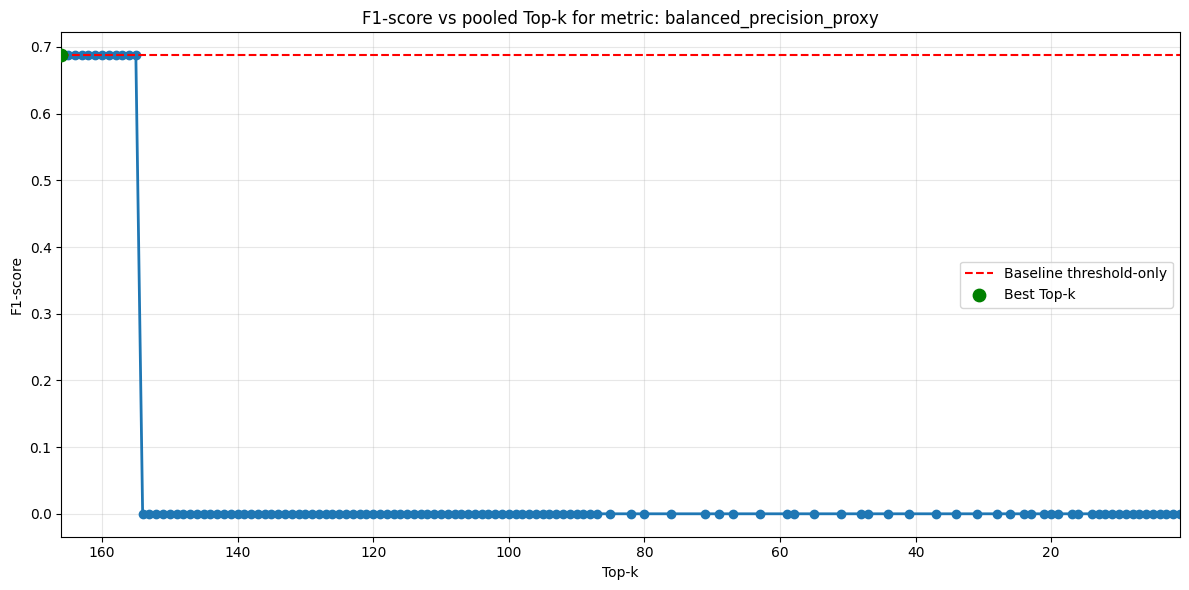

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/balanced_precision_proxy_topk_f1.png
Best k for balanced_precision_proxy: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== youdens_j ===


Evaluating youdens_j: 100%|██████████| 122/122 [00:00<00:00, 143.94it/s]


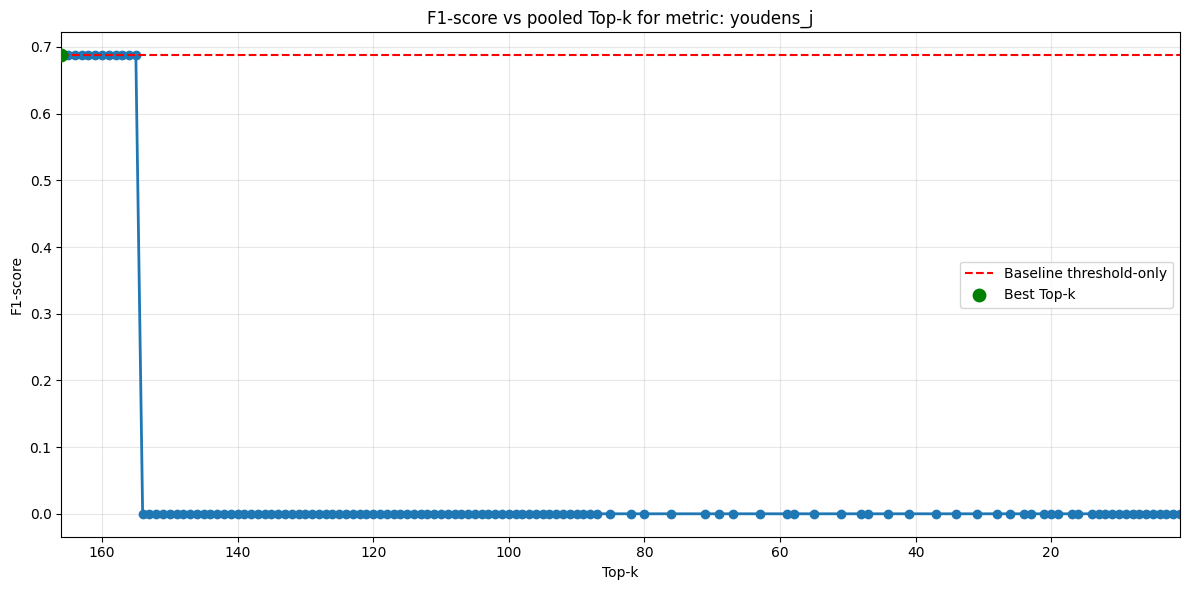

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/youdens_j_topk_f1.png
Best k for youdens_j: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== matthews_correlation ===


Evaluating matthews_correlation: 100%|██████████| 122/122 [00:00<00:00, 145.92it/s]


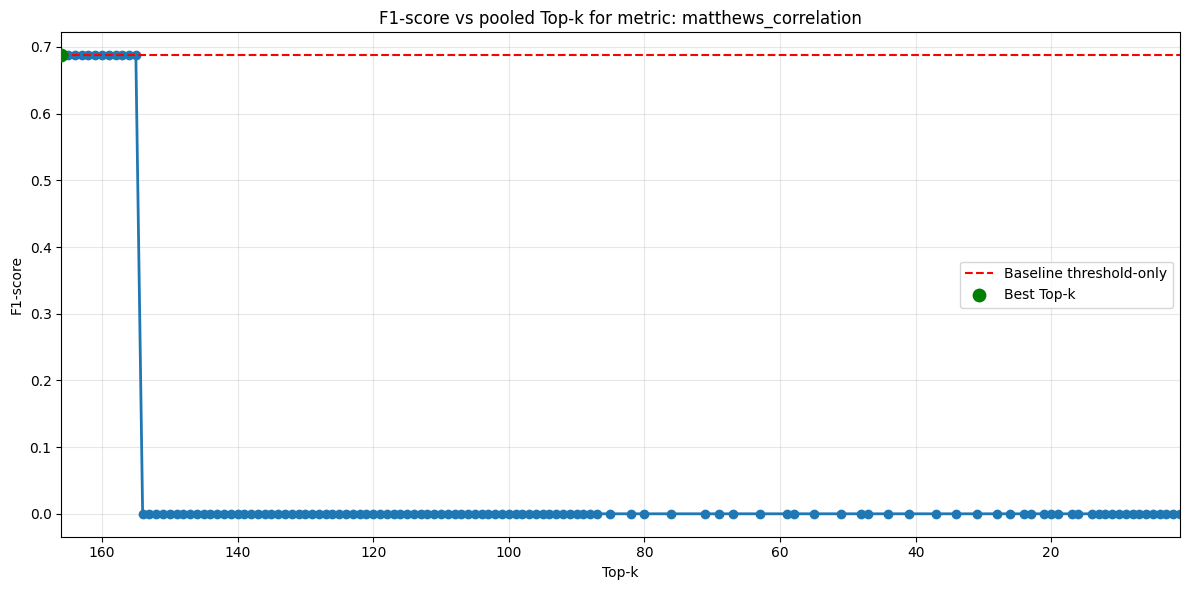

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/matthews_correlation_topk_f1.png
Best k for matthews_correlation: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== information_gain ===


Evaluating information_gain: 100%|██████████| 122/122 [00:00<00:00, 145.00it/s]


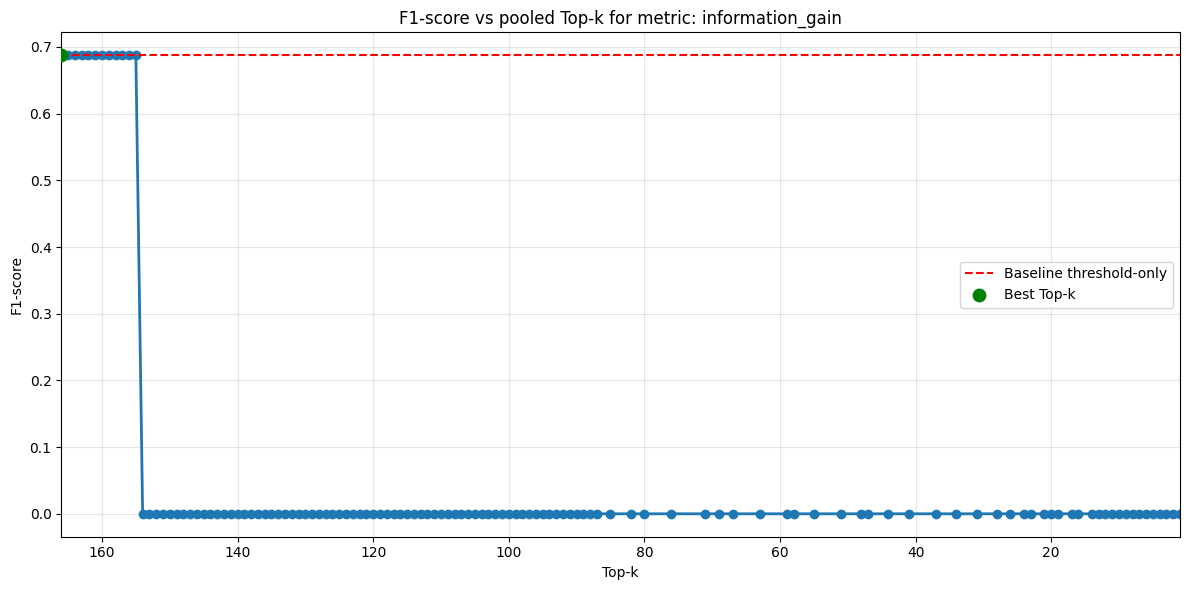

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/information_gain_topk_f1.png
Best k for information_gain: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== gini_gain ===


Evaluating gini_gain: 100%|██████████| 122/122 [00:00<00:00, 149.07it/s]


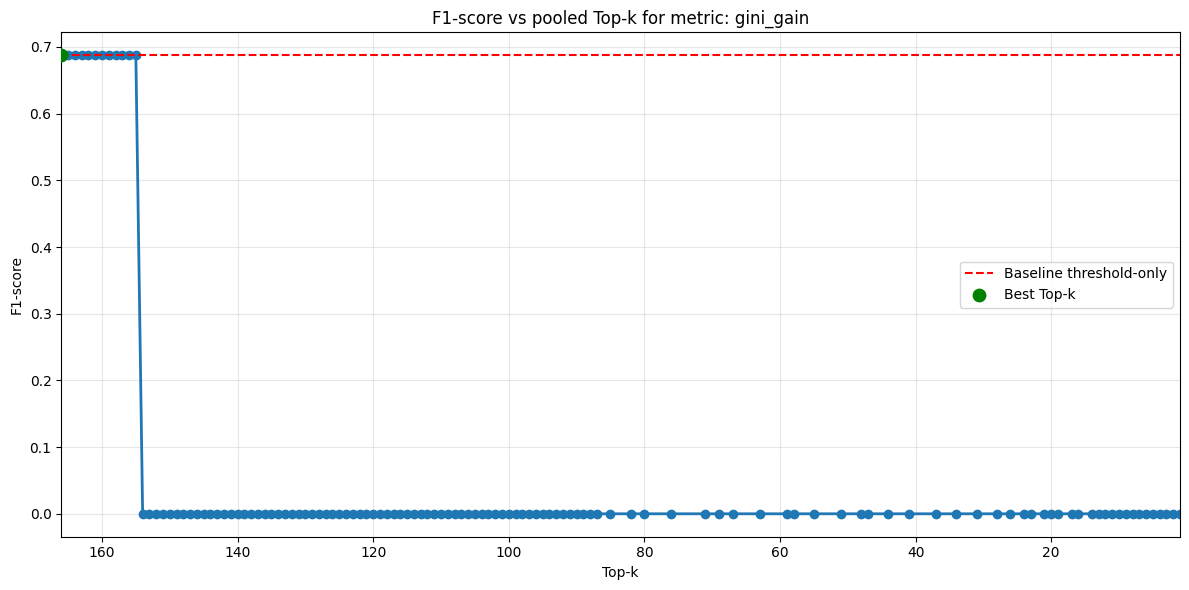

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/gini_gain_topk_f1.png
Best k for gini_gain: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== log_odds_ratio ===


Evaluating log_odds_ratio: 100%|██████████| 122/122 [00:00<00:00, 140.75it/s]


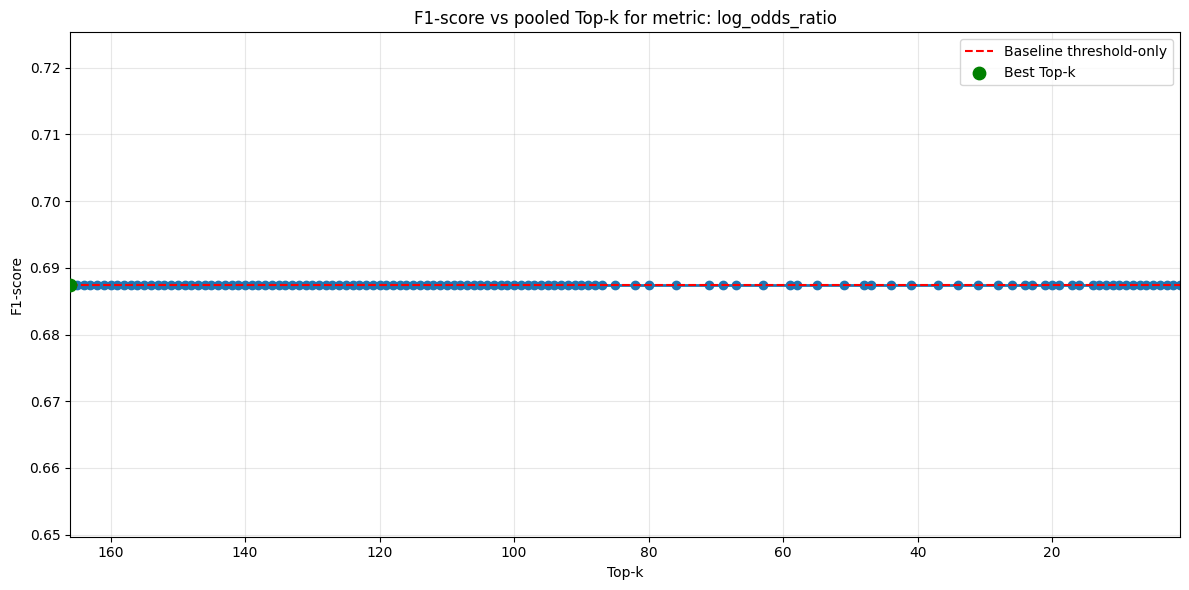

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/log_odds_ratio_topk_f1.png
Best k for log_odds_ratio: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== chi_squared ===


Evaluating chi_squared: 100%|██████████| 122/122 [00:00<00:00, 140.44it/s]


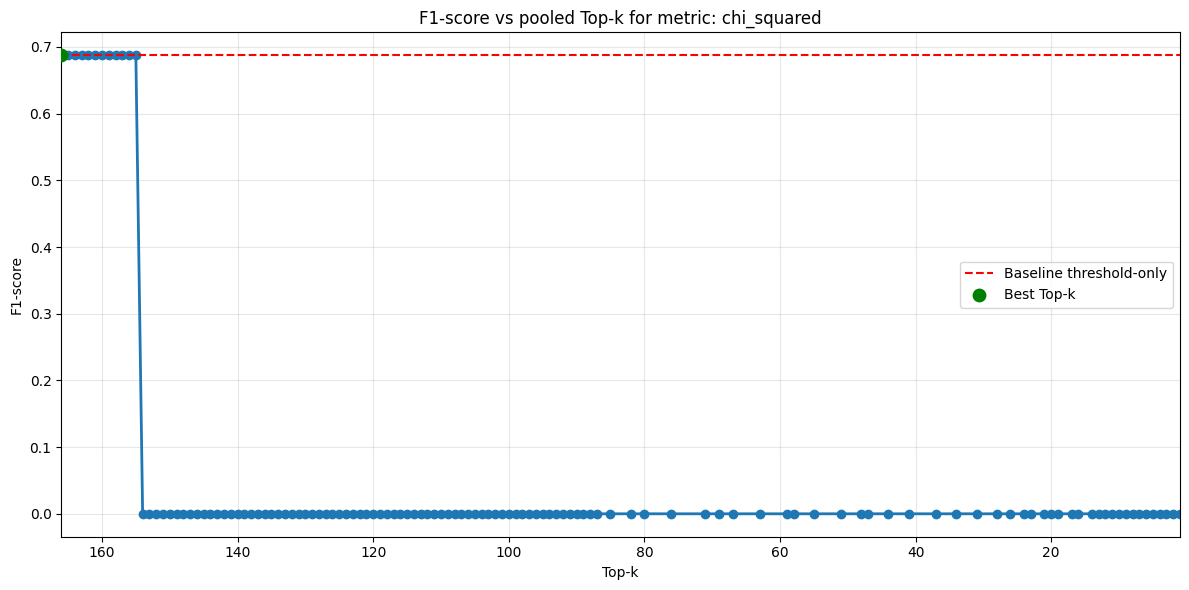

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/chi_squared_topk_f1.png
Best k for chi_squared: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== g_test ===


Evaluating g_test: 100%|██████████| 122/122 [00:00<00:00, 144.65it/s]


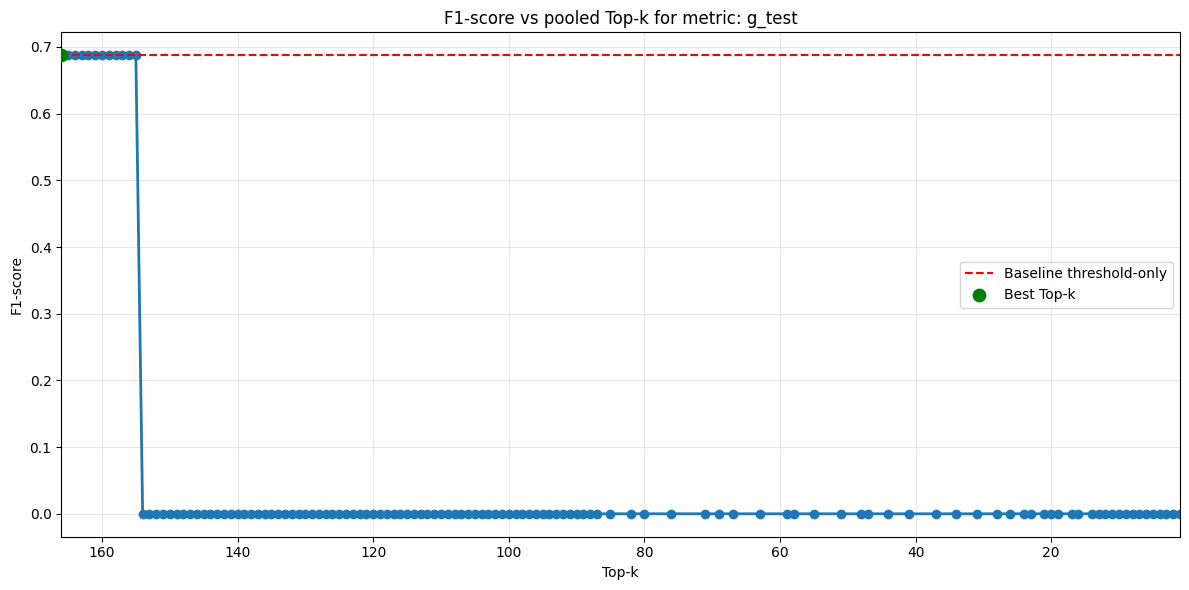

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/g_test_topk_f1.png
Best k for g_test: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== query_weighted_precision ===


Evaluating query_weighted_precision: 100%|██████████| 122/122 [00:00<00:00, 146.28it/s]


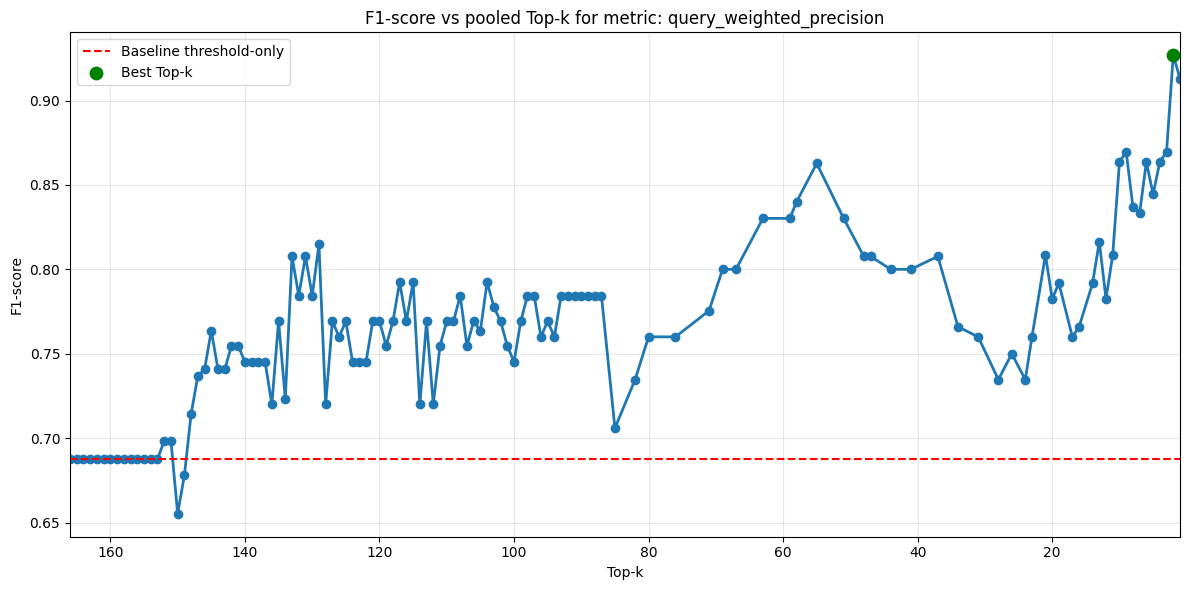

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/query_weighted_precision_topk_f1.png
Best k for query_weighted_precision: 2
Best F1-score: 0.926829
Average classifiers kept: 2.00

=== query_weighted_wracc ===


Evaluating query_weighted_wracc: 100%|██████████| 122/122 [00:00<00:00, 148.06it/s]


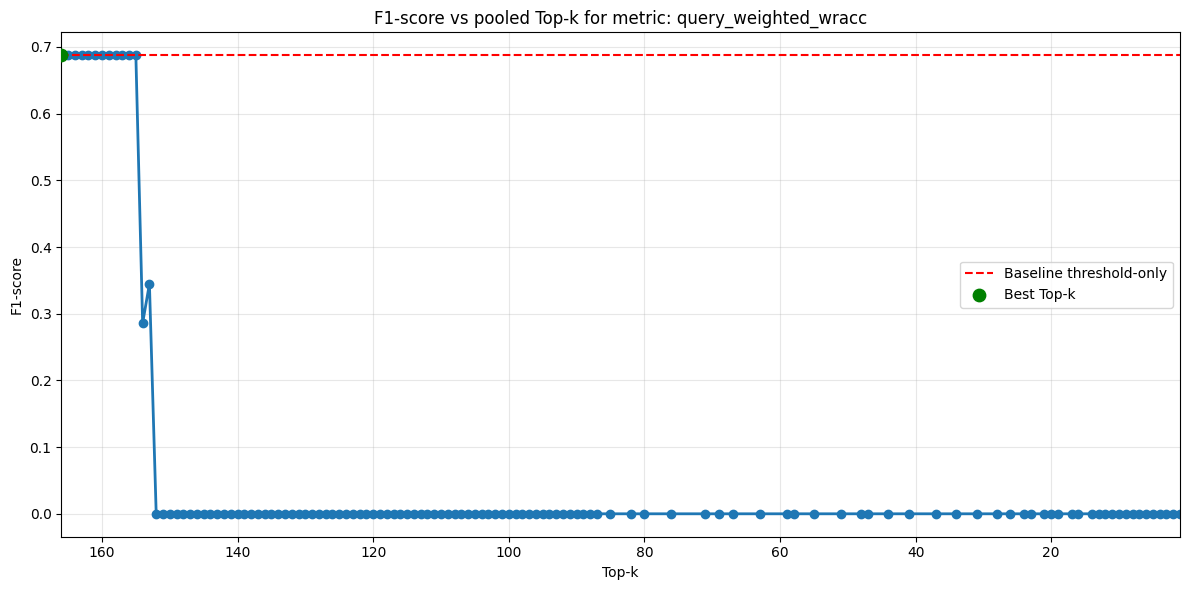

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/query_weighted_wracc_topk_f1.png
Best k for query_weighted_wracc: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== stability ===


Evaluating stability: 100%|██████████| 122/122 [00:00<00:00, 152.81it/s]


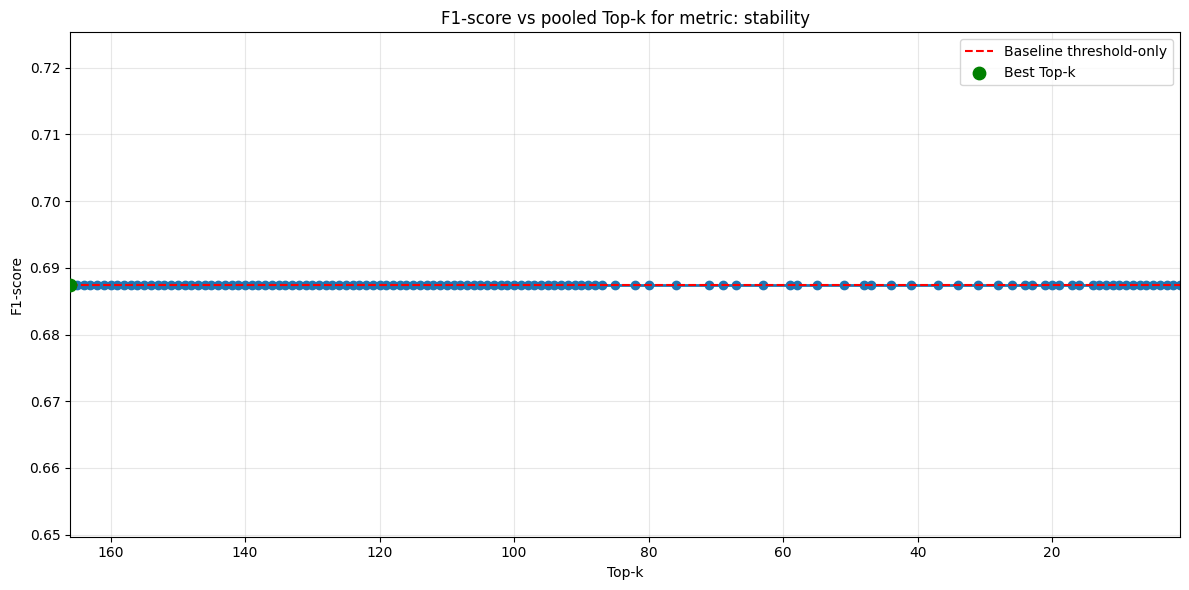

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/stability_topk_f1.png
Best k for stability: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00

=== delta_stability ===


Evaluating delta_stability: 100%|██████████| 122/122 [00:00<00:00, 151.17it/s]


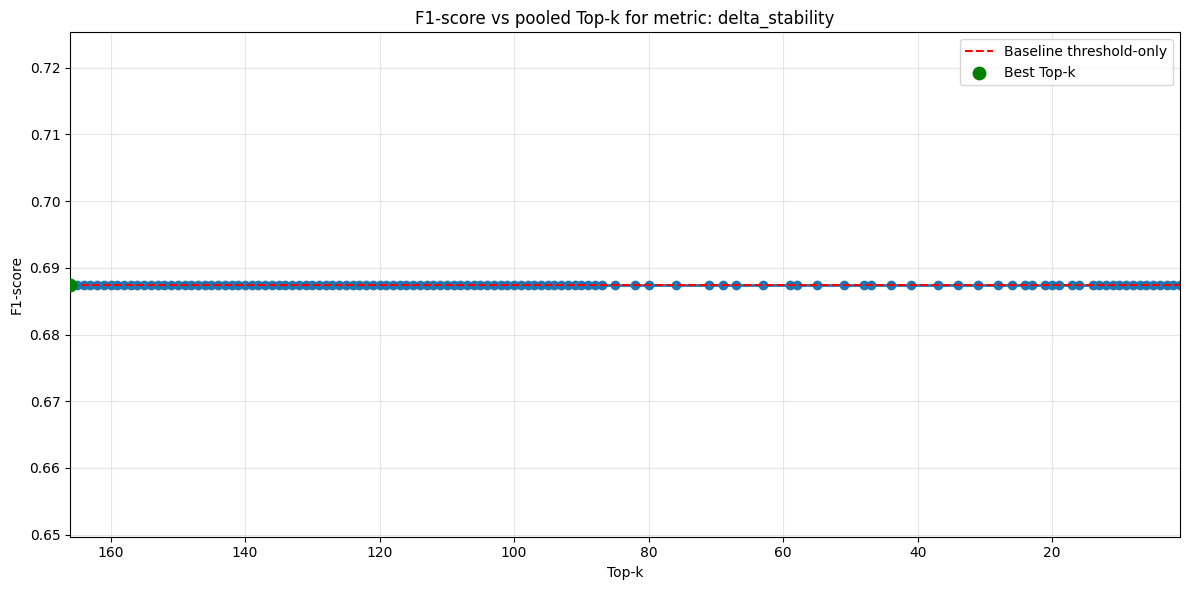

Saved plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/delta_stability_topk_f1.png
Best k for delta_stability: 166
Best F1-score: 0.687500
Average classifiers kept: 166.00


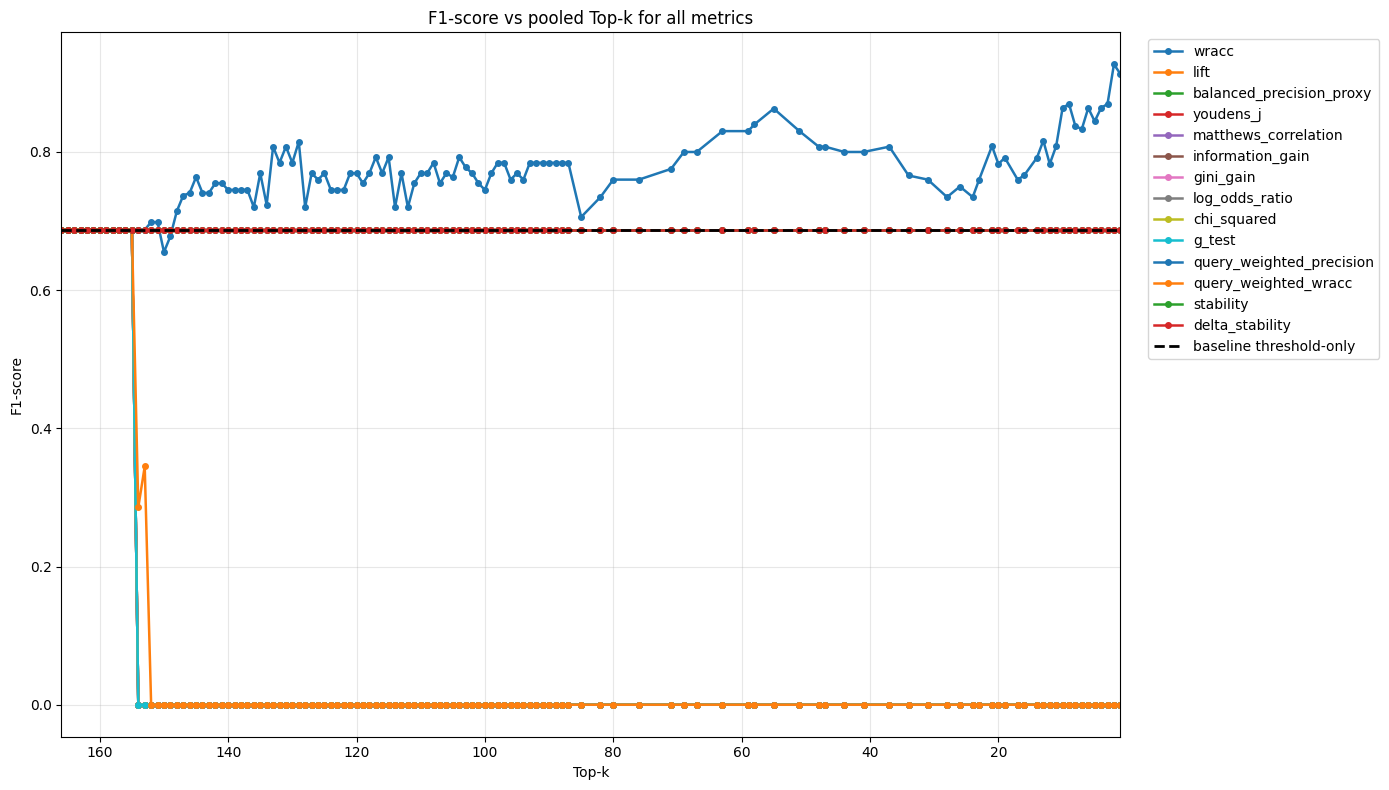


Saved combined plot to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/all_metrics_topk_f1.png
Saved summary CSV to: /home/toretto/Desktop/research/phd/ps_ranking/OSDA-LazyFCA/experiments/generated_plots/sonar_topk_ranking_raw/topk_summary.csv


,metric,best_k,best_f1,avg_classifiers_kept
10,query_weighted_precision,2,0.926829,2.0
0,wracc,166,0.687500,166.0
2,balanced_precision_proxy,166,0.687500,166.0
3,youdens_j,166,0.687500,166.0
4,matthews_correlation,166,0.687500,166.0
1,lift,166,0.687500,166.0
5,information_gain,166,0.687500,166.0
6,gini_gain,166,0.687500,166.0
8,chi_squared,166,0.687500,166.0
7,log_odds_ratio,166,0.687500,166.0


In [30]:
metrics_to_plot = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

all_results = {}
summary_rows = []

for metric_name in metrics_to_plot:
    print(f"\n=== {metric_name} ===")
    results = plot_metric_topk(metric_name, k_values)
    all_results[metric_name] = results.copy()

    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]

    summary_rows.append({
        "metric": metric_name,
        "best_k": int(best_row["k"]),
        "best_f1": float(best_row["F1-score"]),
        "avg_classifiers_kept": float(best_row["Average classifiers kept"]),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="best_f1", ascending=False)
summary_df.to_csv(PLOTS_DIR / "topk_summary.csv", index=False)

# Combined plot with all metrics together
plt.figure(figsize=(14, 8))
for metric_name, results in all_results.items():
    plt.plot(results["k"], results["F1-score"], marker="o", linewidth=1.8, markersize=4, label=metric_name)

plt.axhline(
    baseline_metrics["F1-score"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="baseline threshold-only"
)

plt.xlabel("Top-k")
plt.ylabel("F1-score")
plt.title("F1-score vs pooled Top-k for all metrics")
plt.xlim(max(k_values), min(k_values))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

combined_plot_path = PLOTS_DIR / "all_metrics_topk_f1.png"
plt.savefig(combined_plot_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"\nSaved combined plot to: {combined_plot_path}")
print(f"Saved summary CSV to: {PLOTS_DIR / 'topk_summary.csv'}")

summary_df


In [31]:
metric_name = "query_weighted_precision"
k_value = 20

results = evaluate_metric_topk(metric_name, np.array([k_value]))
row = results.iloc[0]

print(f"Metric: {metric_name}")
print(f"Top-k: {int(row['k'])}")
print(f"F1-score: {row['F1-score']:.6f}")
print(f"Accuracy: {row['Accuracy']:.6f}")
print(f"Precision: {row['Precision']:.6f}")
print(f"Recall: {row['Recall']:.6f}")
print(f"AUC-ROC: {row['AUC-ROC']:.6f}")
print(f"Average classifiers kept: {row['Average classifiers kept']:.2f}")


Evaluating query_weighted_precision: 100%|██████████| 1/1 [00:00<00:00, 132.68it/s]

Metric: query_weighted_precision
Top-k: 20
F1-score: 0.782609
Accuracy: 0.761905
Precision: 0.750000
Recall: 0.818182
AUC-ROC: 0.862500
Average classifiers kept: 20.00


In [32]:
def rank_metrics_by_f1_retention(
    metrics_to_check,
    allowed_drop_percent=5.0,
    k_values=k_values,
    baseline_f1=None,
    explanations=explanations,
    y_true=y_test,
    pos_weight=1.0,
):
    """
    Rank metrics by how aggressively they can prune while keeping F1 within
    an allowed percentage drop from baseline.

    Rule:
    - Let baseline F1 be F_base.
    - Allowed minimum F1 is:
          F_min = F_base * (1 - allowed_drop_percent / 100)
    - We scan k_values in descending order (from large k to small k).
    - As soon as F1 drops below F_min, we stop.
    - The selected k is the last valid k before the break.

    Output:
    - A dataframe ordered best -> worst.
    - Best means smaller retained k first.
    - Ties are broken by higher retained F1.
    """

    if baseline_f1 is None:
        baseline_f1 = float(baseline_metrics["F1-score"])

    if allowed_drop_percent < 0:
        raise ValueError("allowed_drop_percent must be non-negative")

    f1_threshold = baseline_f1 * (1.0 - allowed_drop_percent / 100.0)

    rows = []

    for metric_name in metrics_to_check:
        results = evaluate_metric_topk(
            metric_name=metric_name,
            k_values=k_values,
            explanations=explanations,
            y_true=y_true,
            pos_weight=pos_weight,
        ).sort_values("k", ascending=False).reset_index(drop=True)

        last_valid_row = None
        broke = False

        for _, row in results.iterrows():
            if row["F1-score"] >= f1_threshold:
                last_valid_row = row
            else:
                broke = True
                break

        if last_valid_row is None:
            rows.append({
                "metric": metric_name,
                "selected_k": np.nan,
                "selected_f1": np.nan,
                "baseline_f1": baseline_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": np.nan,
                "status": "never_satisfies_rule",
            })
        else:
            rows.append({
                "metric": metric_name,
                "selected_k": int(last_valid_row["k"]),
                "selected_f1": float(last_valid_row["F1-score"]),
                "baseline_f1": baseline_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": float(last_valid_row["Average classifiers kept"]),
                "status": "break_found" if broke else "all_k_valid",
            })

    summary = pd.DataFrame(rows)

    # Best -> worst:
    # 1) metrics that satisfy the rule
    # 2) among them, smaller selected_k is better
    # 3) if tied, higher F1 is better
    # 4) metrics that never satisfy the rule go last
    summary["valid"] = summary["selected_k"].notna()

    summary = summary.sort_values(
        by=["valid", "selected_k", "selected_f1"],
        ascending=[False, True, False],
        na_position="last",
    ).reset_index(drop=True)

    return summary.drop(columns=["valid"])


In [33]:
metrics_to_check = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

rank_metrics_by_f1_retention(
    metrics_to_check=metrics_to_check,
    allowed_drop_percent=5.0,
)


Evaluating delta_stability: 100%|██████████| 122/122 [00:00<00:00, 145.75it/s]


,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,query_weighted_precision,1,0.913043,0.6875,0.653125,1.0,all_k_valid
1,log_odds_ratio,1,0.687500,0.6875,0.653125,1.0,all_k_valid
2,stability,1,0.687500,0.6875,0.653125,1.0,all_k_valid
3,delta_stability,1,0.687500,0.6875,0.653125,1.0,all_k_valid
4,wracc,155,0.687500,0.6875,0.653125,155.0,break_found
5,lift,155,0.687500,0.6875,0.653125,155.0,break_found
6,balanced_precision_proxy,155,0.687500,0.6875,0.653125,155.0,break_found
7,youdens_j,155,0.687500,0.6875,0.653125,155.0,break_found
8,matthews_correlation,155,0.687500,0.6875,0.653125,155.0,break_found
9,information_gain,155,0.687500,0.6875,0.653125,155.0,break_found


In [34]:
metrics_to_check = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

rank_metrics_by_f1_retention(
    metrics_to_check=metrics_to_check,
    allowed_drop_percent=1.0,
)


Evaluating delta_stability: 100%|██████████| 122/122 [00:00<00:00, 161.04it/s]


,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,log_odds_ratio,1,0.687500,0.6875,0.680625,1.0,all_k_valid
1,stability,1,0.687500,0.6875,0.680625,1.0,all_k_valid
2,delta_stability,1,0.687500,0.6875,0.680625,1.0,all_k_valid
3,query_weighted_precision,151,0.698413,0.6875,0.680625,151.0,break_found
4,wracc,155,0.687500,0.6875,0.680625,155.0,break_found
5,lift,155,0.687500,0.6875,0.680625,155.0,break_found
6,balanced_precision_proxy,155,0.687500,0.6875,0.680625,155.0,break_found
7,youdens_j,155,0.687500,0.6875,0.680625,155.0,break_found
8,matthews_correlation,155,0.687500,0.6875,0.680625,155.0,break_found
9,information_gain,155,0.687500,0.6875,0.680625,155.0,break_found


In [35]:
def rank_metrics_by_f1_retention(
    metrics_to_check,
    allowed_drop_percent=5.0,
    k_values=k_values,
    explanations=explanations,
    y_true=y_test,
    pos_weight=1.0,
):
    """
    Rank metrics by how aggressively they can prune while keeping F1 within
    an allowed percentage drop from that metric's own best F1.

    Rule:
    - For each metric m, compute its whole F1(k) curve.
    - Let F_best(m) be the best F1 reached by that metric.
    - Allowed minimum F1 is:
          F_min(m) = F_best(m) * (1 - allowed_drop_percent / 100)
    - We scan k_values in descending order (from large k to small k).
    - We ignore the initial bad region before the metric first reaches F_min(m).
    - Once the metric has entered the valid region, we keep scanning.
    - As soon as F1 drops below F_min(m), we stop.
    - The selected k is the last valid k before the break.

    Output:
    - A dataframe ordered best -> worst.
    - Best means smaller retained k first.
    - Ties are broken by higher retained F1.
    """

    if allowed_drop_percent < 0:
        raise ValueError("allowed_drop_percent must be non-negative")

    rows = []

    for metric_name in metrics_to_check:
        results = evaluate_metric_topk(
            metric_name=metric_name,
            k_values=k_values,
            explanations=explanations,
            y_true=y_true,
            pos_weight=pos_weight,
        ).sort_values("k", ascending=False).reset_index(drop=True)

        best_f1 = float(results["F1-score"].max())
        f1_threshold = best_f1 * (1.0 - allowed_drop_percent / 100.0)

        seen_valid_region = False
        last_valid_row = None
        broke = False

        for _, row in results.iterrows():
            if row["F1-score"] >= f1_threshold:
                seen_valid_region = True
                last_valid_row = row
            elif seen_valid_region:
                broke = True
                break

        if last_valid_row is None:
            rows.append({
                "metric": metric_name,
                "selected_k": np.nan,
                "selected_f1": np.nan,
                "baseline_f1": best_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": np.nan,
                "status": "never_reaches_own_threshold",
            })
        else:
            rows.append({
                "metric": metric_name,
                "selected_k": int(last_valid_row["k"]),
                "selected_f1": float(last_valid_row["F1-score"]),
                "baseline_f1": best_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": float(last_valid_row["Average classifiers kept"]),
                "status": "break_found" if broke else "all_remaining_k_valid",
            })

    summary = pd.DataFrame(rows)
    summary["valid"] = summary["selected_k"].notna()

    summary = summary.sort_values(
        by=["valid", "selected_k", "selected_f1"],
        ascending=[False, True, False],
        na_position="last",
    ).reset_index(drop=True)

    return summary.drop(columns=["valid"])


In [36]:
rank_metrics_by_f1_retention(metrics_to_check, 5)

Evaluating delta_stability: 100%|██████████| 122/122 [00:00<00:00, 137.30it/s]


,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,query_weighted_precision,1,0.913043,0.926829,0.880488,1.0,all_remaining_k_valid
1,log_odds_ratio,1,0.687500,0.687500,0.653125,1.0,all_remaining_k_valid
2,stability,1,0.687500,0.687500,0.653125,1.0,all_remaining_k_valid
3,delta_stability,1,0.687500,0.687500,0.653125,1.0,all_remaining_k_valid
4,wracc,155,0.687500,0.687500,0.653125,155.0,break_found
5,lift,155,0.687500,0.687500,0.653125,155.0,break_found
6,balanced_precision_proxy,155,0.687500,0.687500,0.653125,155.0,break_found
7,youdens_j,155,0.687500,0.687500,0.653125,155.0,break_found
8,matthews_correlation,155,0.687500,0.687500,0.653125,155.0,break_found
9,information_gain,155,0.687500,0.687500,0.653125,155.0,break_found


In [37]:
rank_metrics_by_f1_retention(metrics_to_check, 1)

Evaluating delta_stability: 100%|██████████| 122/122 [00:00<00:00, 141.21it/s]


,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,log_odds_ratio,1,0.687500,0.687500,0.680625,1.0,all_remaining_k_valid
1,stability,1,0.687500,0.687500,0.680625,1.0,all_remaining_k_valid
2,delta_stability,1,0.687500,0.687500,0.680625,1.0,all_remaining_k_valid
3,query_weighted_precision,2,0.926829,0.926829,0.917561,2.0,break_found
4,wracc,155,0.687500,0.687500,0.680625,155.0,break_found
5,lift,155,0.687500,0.687500,0.680625,155.0,break_found
6,balanced_precision_proxy,155,0.687500,0.687500,0.680625,155.0,break_found
7,youdens_j,155,0.687500,0.687500,0.680625,155.0,break_found
8,matthews_correlation,155,0.687500,0.687500,0.680625,155.0,break_found
9,information_gain,155,0.687500,0.687500,0.680625,155.0,break_found
